<a href="https://colab.research.google.com/github/Hansam123/data-engineering-/blob/main/01_CIRCLE_MODEL_V1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## make some data and get it ready
import sklearn
from sklearn.datasets  import make_circles
n_samples = 1000
## create circle
X, y = make_circles(n_samples, noise = 0.03 , random_state = 42)





In [ ]:
len(X) , len(y)

(1000, 1000)

In [ ]:
print(f"first 5 samples of X : \n {X[ :5]}") ,
print(f"first 5 samples of y :\n {y[:5]}")

first 5 samples of X : 
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first 5 samples of y :
 [1 1 1 1 0]


In [ ]:
## make a data frame of circle data
import pandas as pd
circles = pd.DataFrame({"X1" : X[: , 0 ],
                        "X2" : X[: , 1 ],
                        "label" : y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


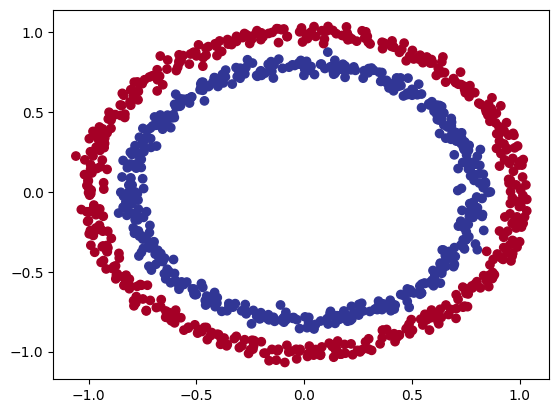

In [ ]:
## visualize , visualize
import matplotlib.pyplot as plt
plt.scatter (x = X[: , 0],
             y = X[: , 1],
             c = y,
             cmap= plt.cm.RdYlBu);

In [ ]:
## 1.1 check and input and output
circles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      1000 non-null   float64
 1   X2      1000 non-null   float64
 2   label   1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [ ]:
X_sample  = X[0]
y_sample = y[0]
print(f"sample of X : {X_sample} and the same of y: {y_sample}")

sample of X : [0.75424625 0.23148074] and the same of y: 1


In [ ]:
## turn the data into set
import torch
torch.__version__

'2.9.0+cpu'

In [ ]:
X = torch.from_numpy(X).type (torch.float)
y = torch.from_numpy(y).type (torch.float)

In [ ]:
X[:5] , y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
## make some data and get it ready (re-included for robustness)
import sklearn
from sklearn.datasets  import make_circles
n_samples = 1000
## create circle
X, y = make_circles(n_samples, noise = 0.03 , random_state = 42)

## turn the data into set (PyTorch tensors, re-included for robustness)
import torch
X = torch.from_numpy(X).type (torch.float)
y = torch.from_numpy(y).type (torch.float)

## split data into training and test
from sklearn.model_selection import train_test_split

X_train , x_test , y_train , y_test = train_test_split(X ,
                                                       y,
                                                       test_size = 0.2 ,
                                                       random_state = 42)

In [ ]:
len(X_train) , len(y_train ) ,len (x_test) , len (y_test)

(800, 800, 200, 200)

In [ ]:
## workflow
#step 1 : agonistic code
#step 2 : construct a model (by subclassing)
#step 4 : loss function and optimizer
# step 5 : create a training and testing loop
import torch
from torch import nn
device = "cuda " if torch.cuda.is_available()else "cpu"

In [ ]:
##step 2: Define the CircleModelV0 class
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2 , out_features = 5)
    self.layer_2 = nn.Linear(in_features = 5 , out_features = 1)

    self.two_linear_layers = nn.Sequential(
        ##nn.Linear(in_features = 2 , out_features = 5 ),
       ## nn.Linear(in_features = 5 , out_features = 1)
    )

  def forward(self , x):
    return self.layer_2(self.layer_1(x))

##step 4: Instantiate the model
model_0 = CircleModelV0().to(device)
model_0 = model_0.to(device)

In [ ]:
model_0 = nn.Sequential (
    nn.Linear(in_features = 2 , out_features = 5) ,
    nn.Linear(in_features = 5 , out_features = 1)

).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1285, -0.0035],
                      [-0.1213, -0.5946],
                      [-0.2969,  0.4242],
                      [-0.2616, -0.4471],
                      [-0.4525, -0.6201]])),
             ('0.bias', tensor([ 0.1905, -0.4510, -0.4013, -0.2656,  0.6818])),
             ('1.weight',
              tensor([[-0.4051,  0.2650,  0.3860, -0.2803,  0.3138]])),
             ('1.bias', tensor([-0.1719]))])

In [ ]:
untrained_preds = model_0(x_test.to(device))
print(f"Length of predictions  : {len(untrained_preds)} , Shape : {untrained_preds.shape}")
print(f"Length of test samples : {len(x_test)} , Shape :{x_test.shape} ")
print(f"\nFirst 10 predictions : \n {untrained_preds[:10]}")

Length of predictions  : 200 , Shape : torch.Size([200, 1])
Length of test samples : 200 , Shape :torch.Size([200, 2]) 

First 10 predictions : 
 tensor([[-0.1768],
        [-0.2984],
        [-0.0277],
        [-0.2184],
        [-0.2969],
        [-0.3690],
        [-0.4980],
        [-0.5152],
        [-0.0166],
        [-0.3095]], grad_fn=<SliceBackward0>)


In [ ]:
##for regressionmean absolute error (mae)
##for classification bineary cross entropy
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr =1)

In [ ]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true , y_pred ).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [ ]:
y_logits  = model_0(x_test.to(device))[:5]
y_logits

tensor([[-0.1768],
        [-0.2984],
        [-0.0277],
        [-0.2184],
        [-0.2969]], grad_fn=<SliceBackward0>)

In [ ]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4559],
        [0.4259],
        [0.4931],
        [0.4456],
        [0.4263]], grad_fn=<SigmoidBackward0>)

In [ ]:
y_preds = torch.round(y_pred_probs)
y_pred_labels = torch.round(torch.sigmoid(model_0(x_test.to(device))[:5]))
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

tensor([True, True, True, True, True])


In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1

X_train , y_train = X_train.to(device), y_train.to(device)
x_test , y_test = x_test.to(device) , y_test.to(device)

# Loop through the data
for epoch in range(epochs):
  # Training
  model_0.train()

  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true = y_train , y_pred = y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing
  model_0.eval()
  with torch.inference_mode() :
    test_logits = model_0(x_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits , y_test)
    test_acc = accuracy_fn(y_true = y_test , y_pred = test_pred )


    if epoch % 10 == 0 : # Changed epochs to epoch here
      print (f"Epochs : {epoch } | loss : {loss:.5f} | acc: {acc:.2f} | test loss: {test_loss:.5f} | , test acc: {test_acc:.2f}%")

Epochs : 0 | loss : 0.70468 | acc: 41.00 | test loss: 0.69392 | , test acc: 51.00%


In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repository (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)
  print("helper_functions.py downloaded")

helper_functions.py downloaded


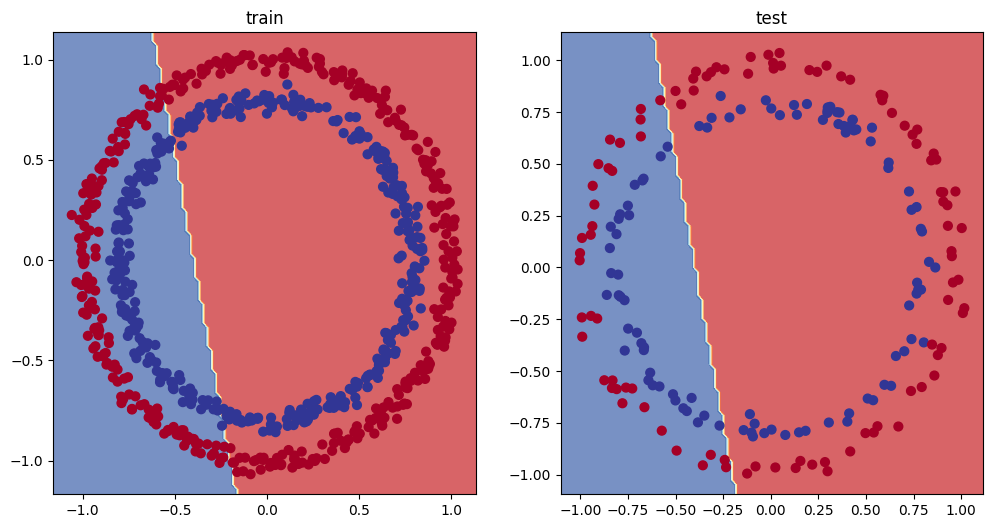

In [ ]:
from helper_functions import plot_predictions , plot_decision_boundary
plt.figure(figsize = (12, 6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_0 , X_train , y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_0 , x_test , y_test)

In [ ]:
##improving a model
##give the model more chance to learn
###more dataset more learn in machine learning
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2 , out_features=10)
    self.layer_2 = nn.Linear(in_features = 10 , out_features=10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

  def forward (self , x):
    z = self.layer_1(x)
    z = self.layer_2(z)
    z = self.layer_3 (z)
    return z

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
##create loss
##create an optimizer
loss_fn = nn.BCEwithLogitsLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr= 0.1)
torch.maunal_seed(42)
torch.cude.manual_seed(42)
epochs = 1000
X_train , y_train = X_train.to(device) , y_train.to(device)
X_test , y_test = X_test.to(device) , y_test.to(device)

for epochs in range(epochs) :
   model_1.train()
   y_logits = model_1(X_train).squeeze()
   y_pred =torch.round (torch.sigmod(y_logits))

loss = loss_fn(y_logits , y_train)
acc = accuracy_fn(y_true = y_train ,
                  y_pred = y_pred)
optimizer.zero_gred()
loss.backward()
optimizer.step(
  model_1.eval()
  with torch.inference_mode():
    test_logtis = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmod(test_logits))


SyntaxError: '(' was never closed (ipython-input-2903499646.py, line 22)

In [ ]:
##fundamental classsification model
### preparing for data to see if our model stright data
weight = 0.7
bais = 0.3
start = 0
end = 1
step = 0.01
#3 crate data
x_regression = torch.arange(start , end , step).unsqueeze(dim=1)
y_regression = weight * x_regression + bais
print (len(x_regression))
x_regression [:5], y_regression [:5]

In [ ]:
##creste train and split
train_split = int(0.8 * len(x_regression))
x_train_regression , y_train_regression = x_regression[:train_split], y_regression[:train_split]
x_test_regression , y_test_regression  = x_regression[train_split:], y_regression[train_split:]

len(x_train_regression) , len(x_test_regression) , len(y_train_regression) , len(y_test_regression)

In [ ]:
plot_predictions(train_data = x_train_regression , train_labels= y_train_regression,
                 test_data = x_test_regression , test_labels= y_test_regression )

In [ ]:
model_1

In [ ]:
model_2 = nn.Sequential(
    nn.Linear(in_features = 1  , out_features = 10),
    nn.Linear(in_features = 10 , out_features = 10),
    nn.Linear(in_features = 10 , out_features = 1)
)

In [ ]:
## loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_2.parameters(),
                             lr=0.1)


In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000
x_train_regression , y_train_regression = x_train_regression.to(device) , y_train_regression.to(device)
x_test_regression , y_test_regression = x_test_regression.to(device) , y_test_regression.to(device)

# training
for epochs in range(epochs):
  y_preds= model_2(x_train_regression)
  loss = loss_fn(y_preds , y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_preds = model_2(x_test_regression)
    test_loss = loss_fn(test_preds ,  y_test_regression)
    if epochs % 100 == 0 :
      print (f"Epochs : {epochs} | loss : {loss:.5f} | test_loss: {test_loss:.5f}")

In [ ]:
model_2.eva()
with torch.inference_mode():
  y_preds = model_2(x_test_regression)
  SU1084985359225
plot_prediction(train_data = x_train_regression)
plot_prediction(test_data = x_test_regression)
plot_predictions

In [ ]:
### combining linear and non linear combinations model\
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples , noise = 0.03 , random_state = 42)
plt.scatter(X[:,0] , X[:,1] , c=y , cmap=plt.cm.RdYlBu);

In [ ]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles # Import make_circles

n_samples = 1000 # Define n_samples again for this cell's scope
X, y = make_circles(n_samples, noise=0.03, random_state=42) # Re-generate X, y as numpy arrays

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train , x_test , y_train , y_test = train_test_split(X, y)
X_train [:5] , y_train[:5]

SyntaxError: invalid syntax (ipython-input-1201794291.py, line 3)